# 01. Map CCFRP Sampled MPAs

This notebook generates a basic map of the marine protected areas (MPAs) that are sampled by the California Collaborative Fisheries Reseach Program. This map is a useful reference for undestanding the spatial spread of the MPAs sampled. 

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

## I. Visualize the Study Sites

Import the California coastline, nearshore network of MPAs, and CCFRP gridcells from the 'Shapefiles' folder included in this repository to explore study area.

In [2]:
grid_cells_shp = "Shapefiles/CCFRP_Grid_Cells/CCFRP_Grid_cell.shp"
grid_cells = gpd.read_file(grid_cells_shp)

ccfrp_mpas_shp = "Shapefiles/CCFRP_MPAs/ccfrp_mpas.shp"
ccfrp_mpas = gpd.read_file(ccfrp_mpas_shp)

ca_coast_shp = "Shapefiles/CA_Coastline/CA_Shoreline.shp"
ca_coast = gpd.read_file(ca_coast_shp)

Convert all shapefiles to WGS84 (EPSG:4326). 

In [3]:
target_crs = "EPSG:4326"

ca_coast = ca_coast.to_crs(target_crs)
ccfrp_mpas = ccfrp_mpas.to_crs(target_crs)
grid_cells = grid_cells.to_crs(target_crs)

Plot the shapefiles to visualize the study sites! 

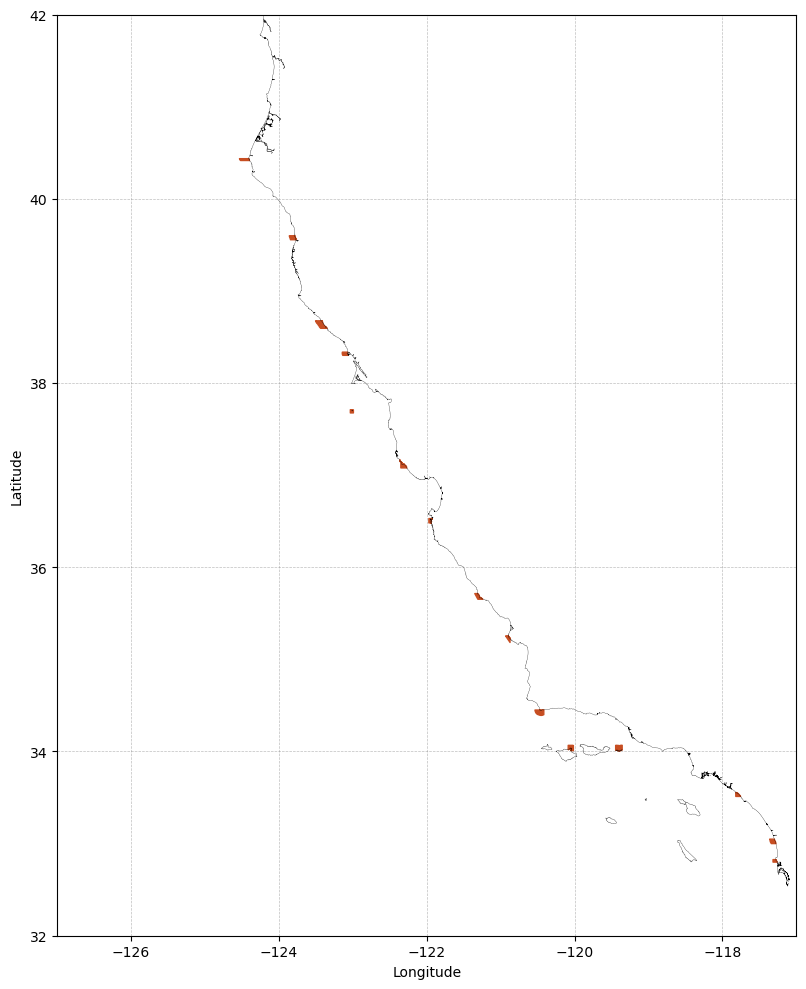

In [5]:
fig, ax = plt.subplots(figsize=(12, 10))

# Plot the coastline and grid cells
ca_coast.plot(ax=ax, color='black', edgecolor='black', linewidth=0.2)
ccfrp_mpas.plot(ax=ax, color='#C74E22', edgecolor='#C74E22', linewidth=1)


ax.set_ylim([32, 42])
ax.set_xlim([-127, -117])


# Label with arrows for specific crowded MPAs
label_overrides = {
    'Carrington Point SMR': (-120, 34.9),
    'Anacapa Island SMCA': (-120, 34.7),
    'Anacapa Island SMR': (-120, 34.5)
}

# The following labeling code was lifted from Chat GPT: 
# First, draw all the normal labels (skip the overridden ones)
#for idx, row in ccfrp_mpas.iterrows():
#    if row.geometry.is_empty:
#        continue
#    name = row['NAME']
#    centroid = row.geometry.centroid
#    if name not in label_overrides:
#        ax.text(centroid.x - 0.08, centroid.y, str(name),
 #               fontsize=10, ha='right', va='center', color='black')

# Then add custom annotations with arrows for crowded labels
#for name, (label_x, label_y) in label_overrides.items():
#    row = ccfrp_mpas[ccfrp_mpas['NAME'] == name].iloc[0]
#    centroid = row.geometry.centroid
#    ax.annotate(name,
#               xy=(centroid.x, centroid.y),           # Point to polygon
#                xytext=(label_x, label_y),              # Place label here
#                textcoords='data',
#                fontsize=10,
#                ha='left',
#                va='center',
#                arrowprops=dict(arrowstyle='->', color='black', lw=0.8),
#                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='gray', lw=0.5))

# Formatting
ax.set_xlabel('Longitude', fontsize=10)
ax.set_ylabel('Latitude', fontsize=10)
ax.tick_params(labelsize=10)
ax.grid(True, which='both', color='gray', linewidth=0.5, linestyle='--', alpha=0.5)
ax.set_ylim([32, 42])
ax.set_xlim([-127, -117])

plt.tight_layout()

plt.savefig('WSN_Figures/CCFRP_MPA_Map_UNLABELED.png', dpi=300, bbox_inches='tight')
plt.show()